# Instacart Customer Analytics & Recommendation System

This project analyzes customer purchasing behavior using the Instacart Market Basket dataset and builds a customer segmentation and product recommendation solution.

## Project Objectives

- Segment customers using RFM (Recency, Frequency, Monetary) analysis
- Estimate Customer Lifetime Value (CLV)
- Identify behavioral and category-preference customer clusters using K-Means
- Build an ALS collaborative filtering recommendation model
- Apply association rule mining for product co-purchase patterns
- Evaluate recommendations using Precision@K and Recall@K
- Develop explainable hybrid product recommendations

## Dataset

**Instacart Market Basket Analysis**  
Source: Kaggle

https://www.kaggle.com/datasets/yasserh/instacart-online-grocery-basket-analysis-dataset/data

## Project Timeline

- Original project completed: December 2025
- Portfolio version published on GitHub: August 2026

# Importing the files and paths

In [28]:
#importing the packages
import pandas as pd
import numpy as np

from pathlib import Path

from scipy.sparse import csr_matrix
import implicit

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

from mlxtend.frequent_patterns import apriori, association_rules

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 100)

In [ ]:
# ---------------------------------------------------------
# Portable project paths
# ---------------------------------------------------------

# Detect project root whether notebook is launched
# from the repository root or from the notebooks folder.
PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

RAW_DIR = PROJECT_ROOT / "data" / "raw"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"

# Create processed-data directory if it does not exist
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

# Raw data files
ORDERS_PATH = RAW_DIR / "orders.csv"
ORDER_PRODUCTS_PRIOR_PATH = RAW_DIR / "order_products__prior.csv"
PRODUCTS_PATH = RAW_DIR / "products.csv"
DEPARTMENTS_PATH = RAW_DIR / "departments.csv"

# Processed files
TRANSACTIONS_PATH = PROCESSED_DIR / "transactions.csv"
RFM_PATH = PROCESSED_DIR / "rfm_users.csv"

In [ ]:
# ---------------------------------------------------------
# Check required raw data files
# ---------------------------------------------------------

required_files = [
    ORDERS_PATH,
    ORDER_PRODUCTS_PRIOR_PATH,
    PRODUCTS_PATH,
    DEPARTMENTS_PATH,
]

missing_files = [path for path in required_files if not path.exists()]

if missing_files:
    missing_names = "\n".join(f"- {path.name}" for path in missing_files)

    raise FileNotFoundError(
        "Required Instacart raw data files were not found.\n\n"
        "Please download the Instacart Market Basket Analysis dataset "
        "and place the following files inside data/raw/:\n"
        f"{missing_names}\n\n"
        "See data/README.md for dataset instructions."
    )

print("All required raw data files are available.")

# Building/ Loading Transactions Table

In [30]:
import gc
from pathlib import Path

RAW_DIR = Path(RAW_DIR)              
PROCESSED_DIR = Path(PROCESSED_DIR)  
TRANSACTIONS_PATH = PROCESSED_DIR / "transactions_sampled.csv"
# -----------------------------------------------------------

if TRANSACTIONS_PATH.exists():
    print("Loading existing *sampled* transactions table...")
    transactions = pd.read_csv(TRANSACTIONS_PATH)
else:
    print("Building *sampled* transactions table from raw Instacart CSVs...")

    # 1) Loading only needed columns here
    orders = pd.read_csv(
        ORDERS_PATH,
        usecols=["order_id", "user_id", "eval_set", "order_number", "days_since_prior_order"]
    )
    order_products_prior = pd.read_csv(
        ORDER_PRODUCTS_PRIOR_PATH,
        usecols=["order_id", "product_id"]
    )
    products = pd.read_csv(
        PRODUCTS_PATH,
        usecols=["product_id", "product_name", "department_id"]
    )

    print("orders shape:", orders.shape)
    print("order_products_prior shape:", order_products_prior.shape)
    print("products shape:", products.shape)

    # 2) Filter to prior orders
    orders_prior = orders[orders["eval_set"] == "prior"].copy()
    del orders
    gc.collect()

    print("orders_prior shape (before sampling):", orders_prior.shape)

    # 3) Sample prior orders to keep processing feasible on local hardware.
# A fixed random seed ensures the sample is reproducible.
    SAMPLE_N_ORDERS = 200_000  

    unique_prior_orders = orders_prior["order_id"].unique()
    print("unique prior orders:", len(unique_prior_orders))

    if len(unique_prior_orders) > SAMPLE_N_ORDERS:
        sampled_ids = pd.Series(unique_prior_orders).sample(
            n=SAMPLE_N_ORDERS,
            random_state=42
        )
        orders_prior = orders_prior[orders_prior["order_id"].isin(sampled_ids)]
        order_products_prior = order_products_prior[
            order_products_prior["order_id"].isin(sampled_ids)
        ]

    print("orders_prior shape (after sampling):", orders_prior.shape)
    print("order_products_prior shape (after sampling):", order_products_prior.shape)

    # 4) Merging prior orders with order_products_prior
    op = order_products_prior.merge(
        orders_prior[["order_id", "user_id", "order_number", "days_since_prior_order"]],
        on="order_id",
        how="inner"
    )
    del order_products_prior
    gc.collect()

    print("op after merge with orders_prior:", op.shape)

    # 5) Merge with products to get product_name + department_id
    op = op.merge(
        products,
        on="product_id",
        how="left"
    )
    del products
    gc.collect()

    print("op after merge with products:", op.shape)

    # 6) Computation of relative days_since_first_order
    orders_prior_sorted = orders_prior.sort_values(["user_id", "order_number"]).copy()
    del orders_prior
    gc.collect()

    orders_prior_sorted["days_since_prior_order_filled"] = orders_prior_sorted["days_since_prior_order"].fillna(0)
    orders_prior_sorted["days_since_first_order"] = orders_prior_sorted.groupby("user_id")[
        "days_since_prior_order_filled"
    ].cumsum()

    orders_time = orders_prior_sorted[["order_id", "user_id", "order_number", "days_since_first_order"]].copy()
    del orders_prior_sorted
    gc.collect()

    print("orders_time shape:", orders_time.shape)

    # 7) Attach days_since_first_order to op
    op = op.merge(
        orders_time[["order_id", "days_since_first_order"]],
        on="order_id",
        how="left"
    )
    del orders_time
    gc.collect()

    print("op after adding days_since_first_order:", op.shape)

    # 8) Final transactions table (sampled)
    transactions = op[[
        "user_id",
        "order_id",
        "order_number",
        "days_since_first_order",
        "product_id",
        "product_name",
        "department_id"
    ]].copy()
    del op
    gc.collect()

    print("final sampled transactions shape:", transactions.shape)

    transactions.to_csv(TRANSACTIONS_PATH, index=False)
    print(f"Saved sampled transactions to {TRANSACTIONS_PATH}")

transactions.head()


Loading existing *sampled* transactions table...


,user_id,order_id,order_number,days_since_first_order,product_id,product_name,department_id
0,139016,9,14,5.0,21405,"Organic Red Radish, Bunch",4
1,139016,9,14,5.0,47890,Whole White Mushrooms,4
2,139016,9,14,5.0,11182,Baby Spinach,4
3,139016,9,14,5.0,2014,Low Fat Kefir Cultured Milk Smoothie Lowfat Pr...,16
4,139016,9,14,5.0,29193,Snak-Saks Crackers,19


# RFM Calculation

In [31]:
def _rfm_score(x, quintiles, reverse=False):
    if x <= quintiles[0.2]:
        score = 1
    elif x <= quintiles[0.4]:
        score = 2
    elif x <= quintiles[0.6]:
        score = 3
    elif x <= quintiles[0.8]:
        score = 4
    else:
        score = 5
    if reverse:
        return 6 - score
    return score


def _rfm_segment(row):
    r, f, m = row["R_score"], row["F_score"], row["M_score"]
    if r >= 4 and f >= 4 and m >= 4:
        return "Champions"
    elif r >= 3 and f >= 3 and m >= 3:
        return "Loyal Customers"
    elif r >= 4 and f <= 2:
        return "Recent Customers"
    elif r <= 2 and f >= 4:
        return "At Risk"
    elif f <= 2 and m <= 2:
        return "Hibernating"
    else:
        return "Others"


if RFM_PATH.exists():
    print("Loading existing RFM table...")
    rfm_users = pd.read_csv(RFM_PATH)
else:
    print("Computing RFM table from transactions...")
    max_global_days = transactions["days_since_first_order"].max()
    user_agg = transactions.groupby("user_id").agg(
        last_order_day=("days_since_first_order", "max"),
        frequency=("order_id", "nunique"),
        monetary=("product_id", "count"),
    ).reset_index()
    user_agg["recency"] = max_global_days - user_agg["last_order_day"]
    user_agg = user_agg[["user_id", "recency", "frequency", "monetary"]]

    recency_quintiles = user_agg["recency"].quantile([0.2, 0.4, 0.6, 0.8]).to_dict()
    frequency_quintiles = user_agg["frequency"].quantile([0.2, 0.4, 0.6, 0.8]).to_dict()
    monetary_quintiles = user_agg["monetary"].quantile([0.2, 0.4, 0.6, 0.8]).to_dict()

    user_agg["R_score"] = user_agg["recency"].apply(_rfm_score, args=(recency_quintiles,), reverse=True)
    user_agg["F_score"] = user_agg["frequency"].apply(_rfm_score, args=(frequency_quintiles,), reverse=False)
    user_agg["M_score"] = user_agg["monetary"].apply(_rfm_score, args=(monetary_quintiles,), reverse=False)

    user_agg["RFM_score"] = (
        user_agg["R_score"].astype(str)
        + user_agg["F_score"].astype(str)
        + user_agg["M_score"].astype(str)
    )

    user_agg["segment"] = user_agg.apply(_rfm_segment, axis=1)
    rfm_users = user_agg.copy()
    rfm_users.to_csv(RFM_PATH, index=False)
    print(f"Saved RFM table to {RFM_PATH}")

rfm_users.head()


Loading existing RFM table...


,user_id,recency,frequency,monetary,R_score,F_score,M_score,RFM_score,segment
0,2,137.0,1,5,1,1,1,111,Hibernating
1,3,113.0,2,13,4,3,3,433,Loyal Customers
2,4,140.0,1,4,1,1,1,111,Hibernating
3,7,127.0,2,13,3,3,3,333,Loyal Customers
4,9,134.0,1,11,2,1,3,213,Others


# CLV Calculation per user & segment

In [ ]:
# CLV proxy:
# The Instacart dataset does not contain product prices.
# Monetary is represented by historical item count, and an assumed
# average item price of $3 is used to create an interpretable value proxy.
AVG_PRICE = 3.0

rfm_users["clv_hist_items"] = rfm_users["monetary"]
rfm_users["clv_value"] = rfm_users["monetary"] * AVG_PRICE

clv_segment_summary = rfm_users.groupby("segment").agg(
    customers=("user_id", "nunique"),
    avg_recency=("recency", "mean"),
    avg_frequency=("frequency", "mean"),
    avg_monetary=("monetary", "mean"),
    avg_clv_items=("clv_hist_items", "mean"),
    avg_clv_value=("clv_value", "mean"),
).reset_index()

clv_segment_summary.sort_values("avg_clv_value", ascending=False)

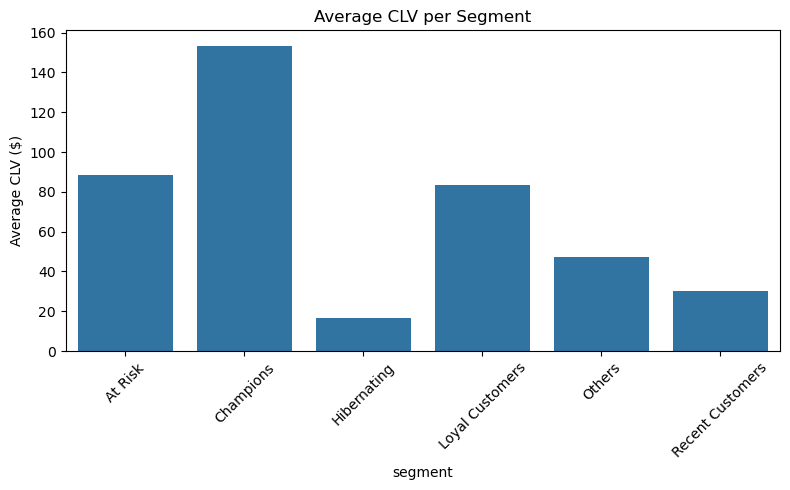

In [33]:
plt.figure(figsize=(8, 5))
sns.barplot(data=clv_segment_summary, x="segment", y="avg_clv_value")
plt.xticks(rotation=45)
plt.ylabel("Average CLV ($)")
plt.title("Average CLV per Segment")
plt.tight_layout()
plt.show()

### Champions (~$150)

This is clearly your most valuable group.

They generate almost 2x the CLV of “At Risk” and 3–5x more than most other segments.

These are your core customers – high priority for retention, loyalty rewards, VIP offers, early access, and personalized recommendations.

### At Risk (~$90)

Historically good customers whose CLV is still relatively high, but their recency/frequency suggests they may be drifting away.

They’re worth saving: targeted win-back campaigns (emails, coupons, reminders) could have a strong ROI.

### Loyal Customers (~$80)

Solid, reliable buyers with good CLV, but not quite at “Champion” level.

Focus on maintaining satisfaction and gently up-selling / cross-selling to move some of them into Champions.

### Others (~$45)

Mid-tier, mixed behavior – neither very recent nor very valuable.

This is a broad “average” bucket. Good testing ground for generic promotions, bundles, or nudges to increase spend or frequency.

### Recent Customers (~$30)

New or newly reactivated shoppers with lower current CLV, but lots of future potential.

Ideal for onboarding journeys: welcome series, first-time discount on second order, recommendations to help them discover the catalog.

### Hibernating (~$15)

Lowest CLV; these customers have bought little and not recently.

Limited return on heavy investment. Use cheap, automated touches (occasional newsletters or big seasonal sales) rather than high-cost campaigns.

# Clustering users based on RFM

In [34]:
rfm_features = rfm_users[["recency", "frequency", "monetary"]].copy()

scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_features)

# Choose k clusters (you can experiment with different values)
kmeans_rfm = KMeans(n_clusters=4, random_state=42, n_init="auto")
rfm_users["rfm_cluster"] = kmeans_rfm.fit_predict(rfm_scaled)

cluster_summary = rfm_users.groupby("rfm_cluster").agg(
    customers=("user_id", "nunique"),
    avg_recency=("recency", "mean"),
    avg_frequency=("frequency", "mean"),
    avg_monetary=("monetary", "mean"),
    avg_clv=("clv_value", "mean"),
).reset_index()

cluster_summary


,rfm_cluster,customers,avg_recency,avg_frequency,avg_monetary,avg_clv
0,0,18206,111.046303,3.419697,36.877842,110.633527
1,1,51337,132.115667,1.255566,11.537780,34.613339
2,2,28667,109.307427,1.482053,12.138557,36.415670
3,3,5105,101.839765,6.032909,79.926347,239.779040


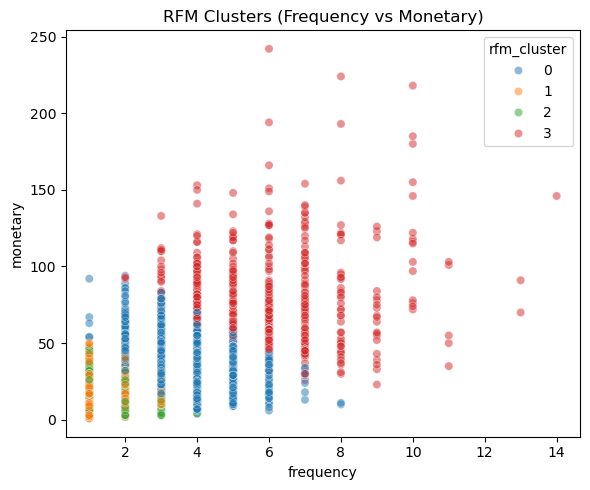

In [35]:
cluster_palette = {
    0: "tab:blue",
    1: "tab:orange",
    2: "tab:green",
    3: "tab:red",
}

plt.figure(figsize=(6, 5))
sns.scatterplot(
    data=rfm_users.sample(min(10000, len(rfm_users)), random_state=42),
    x="frequency",
    y="monetary",
    hue="rfm_cluster",
    palette=cluster_palette,
    alpha=0.5
)

plt.title("RFM Clusters (Frequency vs Monetary)")
plt.tight_layout()
plt.show()

# Interpretation 

Axes & colour:

X-axis – frequency: how many orders the user has placed in the period.

Y-axis – monetary: total spend (or total basket value) per user.

Colour – rfm_cluster (0, 1, 2, 3): the segment assigned by your RFM-based clustering.

Each dot = one user.

## Cluster-by-cluster interpretation 

### Cluster 0 (blue)

Mostly between frequency 2–7 and monetary 20–70.

These are regular but mid-value shoppers: they buy a few times, spend a moderate amount each time, but rarely reach the very high spend levels.

Good candidates for loyalty nudges / small incentives to increase basket size.

### Cluster 1 (orange)

Concentrated at the very bottom-left: low frequency (often 1–2 orders) and low spend (around 0–30).

These look like new / one-time / very low-value customers.

Marketing focus: welcome / reactivation campaigns, simple discounts to bring them back.

### Cluster 2 (green)

Also low frequency (roughly 1–3), but some points reach moderate monetary values.

Think of them as “infrequent but decent spend” shoppers – they don’t come often, but when they do, they buy a bit more than cluster 1.

Could be targeted with reminders or seasonal offers to increase visit frequency.

### Cluster 3 (red)

Spread across higher frequency (up to ~14 orders) with higher monetary values (often 60–200+).

These are your high-value / loyal customers – they order frequently and spend a lot.

Ideal for premium programs, early access, cross-sell/upsell recommendations.

In [36]:
#Tabular description of the clusters
rfm_summary = (
    rfm_users
    .groupby("rfm_cluster")
    .agg(
        customer_count=("user_id", "nunique"),   # or "customer_id" if that's your column
        avg_recency=("recency", "mean"),
        avg_frequency=("frequency", "mean"),
        avg_monetary=("monetary", "mean")
    )
    .round(2)
    .sort_index()
)

segment_labels = {
    0: "Regular mid-value shoppers",
    1: "One-time / very low-value",
    2: "Infrequent but decent spend",
    3: "High-value loyal customers",
}

rfm_summary["segment_label"] = rfm_summary.index.map(segment_labels)
rfm_summary


,customer_count,avg_recency,avg_frequency,avg_monetary,segment_label
rfm_cluster,,,,,
0,18206,111.05,3.42,36.88,Regular mid-value shoppers
1,51337,132.12,1.26,11.54,One-time / very low-value
2,28667,109.31,1.48,12.14,Infrequent but decent spend
3,5105,101.84,6.03,79.93,High-value loyal customers


# Clustering users by product category preferences

In [37]:
# Load departments for category labels
departments = pd.read_csv(DEPARTMENTS_PATH)
products = pd.read_csv(PRODUCTS_PATH)

prod_dept = products.merge(departments, on="department_id", how="left")
prod_dept = prod_dept[["product_id", "department"]]

transactions_dept = transactions.merge(prod_dept, on="product_id", how="left")

# User x department matrix
user_dept = (
    transactions_dept
    .groupby(["user_id", "department"])["product_id"]
    .count()
    .unstack()
    .fillna(0)
)

# Convert to proportions (preference profile)
user_dept_prop = user_dept.div(user_dept.sum(axis=1), axis=0).fillna(0)

kmeans_dept = KMeans(n_clusters=5, random_state=42, n_init="auto")
user_dept_prop["dept_cluster"] = kmeans_dept.fit_predict(user_dept_prop.values)

user_dept_prop.head()

department,alcohol,babies,bakery,beverages,breakfast,bulk,canned goods,dairy eggs,deli,dry goods pasta,frozen,household,international,meat seafood,missing,other,pantry,personal care,pets,produce,snacks,dept_cluster
user_id,,,,,,,,,,,,,,,,,,,,,,
2,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.200000,0.400000,0.0,0.000000,0.00,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.200000,0.200000,2
3,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.153846,0.000000,0.0,0.153846,0.00,0.0,0.0,0.0,0.0,0.153846,0.0,0.0,0.384615,0.153846,2
4,0.0,0.0,0.250000,0.250000,0.0,0.0,0.0,0.000000,0.000000,0.0,0.250000,0.25,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.000000,0
7,0.0,0.0,0.076923,0.307692,0.0,0.0,0.0,0.230769,0.076923,0.0,0.000000,0.00,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.153846,0.153846,0
9,0.0,0.0,0.090909,0.181818,0.0,0.0,0.0,0.454545,0.000000,0.0,0.000000,0.00,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.272727,0.000000,3


In [38]:
# Join department cluster back to RFM table
dept_cluster_df = user_dept_prop["dept_cluster"].reset_index()
rfm_users = rfm_users.merge(dept_cluster_df, on="user_id", how="left")

rfm_users[["user_id", "segment", "rfm_cluster", "dept_cluster"]].head()

,user_id,segment,rfm_cluster,dept_cluster
0,2,Hibernating,1,2
1,3,Loyal Customers,2,2
2,4,Hibernating,1,0
3,7,Loyal Customers,1,0
4,9,Others,1,3


# Evaluation: Precision & Recall @k for ALS CF

In [39]:
# Build train/test split by last order_number
user_last_order = transactions.groupby("user_id")["order_number"].max().reset_index()
user_last_order = user_last_order.rename(columns={"order_number": "last_order_number"})

tx_split = transactions.merge(user_last_order, on="user_id", how="left")

train_tx = tx_split[tx_split["order_number"] < tx_split["last_order_number"]].copy()
test_tx = tx_split[tx_split["order_number"] == tx_split["last_order_number"]].copy()

train_tx.shape, test_tx.shape

((967307, 8), (1052406, 8))

In [40]:
# 6.0 Time-based train/test split (last order per user = test)

# Ensure transactions exists (sampled transactions table)
print("transactions shape:", transactions.shape)

# Sort by user + order_number to identify last order
transactions_sorted = transactions.sort_values(["user_id", "order_number"])

# Last order per user
last_orders = (
    transactions_sorted
    .groupby("user_id")
    .tail(1)[["user_id", "order_id"]]
)

last_order_ids = last_orders["order_id"].unique()

# Test = last order for each user
test_tx = transactions[transactions["order_id"].isin(last_order_ids)].copy()

# Train = all other orders
train_tx = transactions[~transactions["order_id"].isin(last_order_ids)].copy()

print("train_tx shape:", train_tx.shape)
print("test_tx shape:", test_tx.shape)

# Ground-truth items in the test order for each user
test_items = (
    test_tx
    .groupby("user_id")["product_id"]
    .apply(set)
    .to_dict()
)

len(test_items)


transactions shape: (2019713, 7)
train_tx shape: (967307, 7)
test_tx shape: (1052406, 7)


103315

# Training of ALS Model on Train Data

In [41]:
from scipy.sparse import csr_matrix
import implicit

# Build interaction counts
train_counts = (
    train_tx
    .groupby(["user_id", "product_id"])
    .size()
    .reset_index(name="interaction")
)

# User / product index mappings
unique_users_train = train_counts["user_id"].unique()
unique_products_train = train_counts["product_id"].unique()

user_to_index = {u: i for i, u in enumerate(unique_users_train)}
index_to_user = {i: u for u, i in user_to_index.items()}
product_to_index = {p: i for i, p in enumerate(unique_products_train)}
index_to_product = {i: p for p, i in product_to_index.items()}

train_counts["user_idx"] = train_counts["user_id"].map(user_to_index)
train_counts["product_idx"] = train_counts["product_id"].map(product_to_index)

rows = train_counts["user_idx"].values           # user indices
cols = train_counts["product_idx"].values       # item indices
data = train_counts["interaction"].astype(float).values

# USER × ITEM matrix (this is what ALS will be fit on)
train_user_item = csr_matrix(
    (data, (rows, cols)),
    shape=(len(unique_users_train), len(unique_products_train))
)

print("train_user_item shape:", train_user_item.shape)

# Train ALS on USER×ITEM matrix
als_model_eval = implicit.als.AlternatingLeastSquares(
    factors=50,
    regularization=0.01,
    iterations=20,
    random_state=42
)

als_model_eval.fit(train_user_item)


train_user_item shape: (46976, 33340)


  0%|          | 0/20 [00:00<?, ?it/s]

In [43]:
print("Model trained; factors shape:", als_model_eval.item_factors.shape, als_model_eval.user_factors.shape)


Model trained; factors shape: (33340, 50) (46976, 50)


# Build Test Ground Truth and Metrics Functions

In [44]:
import numpy as np

def recommend_cf_ids(user_id, model, user_to_idx, idx_to_product, user_item_matrix, k=10):
    """
    Return a list of product_ids recommended for this user.
    Uses implicit's recommend(userid, user_items_row) API.
    """
    if user_id not in user_to_idx:
        return []

    u_idx = user_to_idx[user_id]

    # Single-row CSR for this user (shape 1 × num_items)
    user_row = user_item_matrix[u_idx]

    # implicit returns (item_indices, scores)
    item_indices, scores = model.recommend(
        userid=u_idx,
        user_items=user_row,
        N=k,
        filter_already_liked_items=True,
    )

    # Map internal item indices back to product_ids
    return [idx_to_product[int(i)] for i in item_indices]


def precision_recall_at_k(model, user_item_matrix, user_to_idx, idx_to_product, test_items_dict, k=10):
    precisions = []
    recalls = []

    for user_id, true_items in test_items_dict.items():
        if user_id not in user_to_idx or len(true_items) == 0:
            continue

        pred_items = set(
            recommend_cf_ids(
                user_id, model, user_to_idx, idx_to_product, user_item_matrix, k=k
            )
        )

        if not pred_items:
            continue

        intersection = pred_items & true_items
        prec = len(intersection) / len(pred_items)
        rec = len(intersection) / len(true_items)

        precisions.append(prec)
        recalls.append(rec)

    precision_k = np.mean(precisions) if precisions else 0.0
    recall_k = np.mean(recalls) if recalls else 0.0
    return precision_k, recall_k


# Compute Precision@k & Recall@k

In [45]:
p5, r5 = precision_recall_at_k(
    als_model_eval, train_user_item, user_to_index, index_to_product, test_items, k=5
)
p10, r10 = precision_recall_at_k(
    als_model_eval, train_user_item, user_to_index, index_to_product, test_items, k=10
)

print(f"Precision@5 = {p5:.4f}, Recall@5 = {r5:.4f}")
print(f"Precision@10 = {p10:.4f}, Recall@10 = {r10:.4f}")

Precision@5 = 0.0264, Recall@5 = 0.0147
Precision@10 = 0.0230, Recall@10 = 0.0250


In [46]:
some_user = next(iter(test_items.keys()))
print("User:", some_user)
print("True items:", test_items[some_user])

preds = recommend_cf_ids(
    some_user, als_model_eval, user_to_index, index_to_product, train_user_item, k=10
)
print("Predicted items:", preds)
print("Overlap:", set(preds) & test_items[some_user])


User: 2
True items: {7781, 28874, 47766, 32792, 20574}
Predicted items: []
Overlap: set()


In [47]:
evaluated_users = [
    u for u, true_items in test_items.items()
    if (u in user_to_index) and (len(true_items) > 0)
]
len(evaluated_users)


46976

In [48]:
def first_user_with_recs(k=10):
    for u, true_items in test_items.items():
        if u not in user_to_index or len(true_items) == 0:
            continue
        preds = recommend_cf_ids(u, als_model_eval, user_to_index, index_to_product, train_user_item, k=k)
        if preds:  # non-empty
            return u, true_items, preds

user_id, true_items, preds = first_user_with_recs(k=10)
print("User:", user_id)
print("True items:", true_items)
print("Predicted items:", preds)
print("Overlap:", set(preds) & true_items)

User: 3
True items: {24810, 9387, 44683, 14992, 22035, 47766, 39190, 1819}
Predicted items: [28204, 45066, 23909, 44142, 44359, 41787, 10749, 28842, 29487, 19057]
Overlap: set()


# Adding Explainability to Hybrid Recommendations

We'll extend the **hybrid recommendation** logic to attach human-readable explanations:

- For **CF** items: generic explanation based on similar users
- For **RULE** (association-rule) items: specific explanation like:
  > Because you bought *X*, customers often also buy *Y* (lift = …)

In [ ]:
# Build full CF model and association rules once for explainability demo
products = pd.read_csv(PRODUCTS_PATH)
product_lookup = products.set_index("product_id")["product_name"].to_dict()

# CF on all transactions (not just train) for demo
cf_counts = transactions.groupby(["user_id", "product_id"]).size().reset_index(name="interaction")
u_ids = cf_counts["user_id"].unique()
p_ids = cf_counts["product_id"].unique()

u2i = {u: i for i, u in enumerate(u_ids)}
i2u = {i: u for u, i in u2i.items()}
p2i = {p: i for i, p in enumerate(p_ids)}
i2p = {i: p for p, i in p2i.items()}

cf_counts["user_idx"] = cf_counts["user_id"].map(u2i)
cf_counts["product_idx"] = cf_counts["product_id"].map(p2i)

rows = cf_counts["user_idx"].values
cols = cf_counts["product_idx"].values
data = cf_counts["interaction"].astype(float).values

user_item_matrix_full = csr_matrix((data, (rows, cols)), shape=(len(u_ids), len(p_ids)))
#item_user_matrix_full = user_item_matrix_full.T

als_model_full = implicit.als.AlternatingLeastSquares(
    factors=50,
    regularization=0.01,
    iterations=20,
    random_state=42
)
als_model_full.fit(user_item_matrix_full)

# Association rules (sampled orders + top products to reduce size)
N_ORDERS = 10_000        # was 50_000
N_TOP_PRODUCTS = 500     # keep only 500 most frequent products

# 1) Sample a subset of orders
sample_orders = (
    transactions["order_id"]
    .drop_duplicates()
    .sample(n=N_ORDERS, random_state=42)
)

# 2) Within those orders, keep only top-N frequent products
top_products = (
    transactions[transactions["order_id"].isin(sample_orders)]["product_id"]
    .value_counts()
    .head(N_TOP_PRODUCTS)
    .index
)

basket_df = transactions[
    (transactions["order_id"].isin(sample_orders)) &
    (transactions["product_id"].isin(top_products))
].copy()

# 3) Build order × product basket matrix (bool)
basket = (
    basket_df
    .groupby(["order_id", "product_id"])["product_id"]
    .count()
    .unstack()
    .fillna(0)
)

basket = basket.astype(bool)  # True/False matrix for apriori

print("basket shape:", basket.shape)

frequent_itemsets = apriori(
    basket,
    min_support=0.01,
    use_colnames=True
)

rules = association_rules(
    frequent_itemsets,
    metric="lift",
    min_threshold=1.0
)
rules["antecedent_len"] = rules["antecedents"].apply(lambda x: len(x))
rules["consequent_len"] = rules["consequents"].apply(lambda x: len(x))
rules = rules.sort_values("lift", ascending=False)


In [50]:
def recommend_products_cf_explain(
    user_id,
    model,
    user_to_idx,
    idx_to_product,
    user_item_matrix,
    product_lookup,
    N=10
):
    """
    CF recommendations for explainability:
    returns a list of dicts with columns:
      - product_id
      - product_name
      - score
      - source
      - explanation
    so that it is compatible with hybrid_recommendation_explain().
    """
    if user_id not in user_to_idx:
        return []

    u_idx = user_to_idx[user_id]

    # 1-row CSR for this user
    user_row = user_item_matrix[u_idx]

    # Recalculate user factors from this row to avoid index issues
    item_indices, scores = model.recommend(
        userid=0,                 # dummy id
        user_items=user_row,      # 1-row CSR
        N=N,
        filter_already_liked_items=True,
        recalculate_user=True
    )

    results = []
    for raw_idx, score in zip(item_indices, scores):
        raw_idx = int(raw_idx)

        # Try to map internal index -> product_id
        if raw_idx in idx_to_product:
            product_id = idx_to_product[raw_idx]
        else:
            # Fallback: treat as product_id directly
            product_id = raw_idx

        product_name = product_lookup.get(product_id, f"Product {product_id}")

        results.append({
            "product_id":   product_id,
            "product_name": product_name,
            "score":        float(score),
            "source":       "CF (ALS)",
            "explanation":  f"Recommended by ALS collaborative filtering (score={score:.3f})"
        })

    return results





def get_also_bought_products_explain(product_id, rules_df, product_lookup, top_k=5):
    filtered = rules_df[rules_df["antecedents"].apply(lambda x: product_id in x)]
    filtered = filtered.sort_values(["lift", "confidence"], ascending=False)
    recs = []
    for _, row in filtered.head(top_k).iterrows():
        for p in row["consequents"]:
            product_name = product_lookup.get(p, f"Product {p}")
            base_product_name = product_lookup.get(product_id, f"Product {product_id}")
            explanation = (
                f"Because you bought '{base_product_name}', customers often also buy "
                f"'{product_name}' (lift={row['lift']:.2f})."
            )
            recs.append({
                "product_id": p,
                "product_name": product_name,
                "support": float(row["support"]),
                "confidence": float(row["confidence"]),
                "lift": float(row["lift"]),
                "source": "RULE",
                "explanation": explanation
            })
    # Deduplicate by product_id
    seen = set()
    unique_recs = []
    for r in recs:
        if r["product_id"] not in seen:
            seen.add(r["product_id"])
            unique_recs.append(r)
    return unique_recs[:top_k]


def hybrid_recommendation_explain(user_id, model, user_to_idx, idx_to_product, user_item_matrix, rules_df, product_lookup,
                                  top_n_cf=5, top_n_rules=2):
    cf_recs = recommend_products_cf_explain(
        user_id=user_id,
        model=model,
        user_to_idx=user_to_idx,
        idx_to_product=idx_to_product,
        user_item_matrix=user_item_matrix,
        product_lookup=product_lookup,
        N=top_n_cf
    )

    hybrid_list = []
    for cf_item in cf_recs:
        hybrid_list.append(cf_item)
        also_bought = get_also_bought_products_explain(cf_item["product_id"], rules_df, product_lookup, top_k=top_n_rules)
        hybrid_list.extend(also_bought)

    if not hybrid_list:
        return pd.DataFrame(columns=["product_id", "product_name", "max_score", "sources", "example_explanation"])

    df = pd.DataFrame(hybrid_list)
    df_agg = df.groupby(["product_id", "product_name"]).agg(
        max_score=("score", "max"),
        sources=("source", lambda x: ",".join(sorted(set(x)))),
        example_explanation=("explanation", "first")
    ).reset_index()
    df_agg = df_agg.sort_values("max_score", ascending=False)
    return df_agg


# Explainable Recommendations for a Sample User

In [ ]:
# Pick a random user for explainability demo
sample_user = np.random.choice(u_ids)
print("Sample user:", sample_user)

explainable_recs = hybrid_recommendation_explain(
    user_id=sample_user,
    model=als_model_full,
    user_to_idx=u2i,
    idx_to_product=i2p,
    user_item_matrix=user_item_matrix_full,
    rules_df=rules,
    product_lookup=product_lookup,
    top_n_cf=5,
    top_n_rules=2
)

explainable_recs.head(15)

# Role of the Recommender in Segment Strategy

### Our ALS-based recommender and hybrid explainability layer can be tailored to each segment:

For Champions and Loyal Customers, we can use the recommender to surface high-margin, complementary products and new categories they have not tried yet.

For At Risk customers, recommendations can focus on past favourites and re-order lists to reduce friction and remind them of their usual purchases.

For Recent Customers, the model can highlight popular products among Champions and curated “starter packs” to help them discover the catalog quickly.

Explainable recommendations (e.g., “Because you often buy organic milk and cereal, we recommend X”) make the system more transparent and can improve user trust and engagement.

# Limitations and Future Work

The analysis uses a reproducible sample of 200,000 prior orders to keep processing feasible on local hardware. As a result, customer segment distributions and recommendation-model performance may differ from results obtained using the complete transaction dataset.

The CLV measure used in this project is a simplified proxy rather than actual customer lifetime value. Because the Instacart dataset does not provide product prices, the Monetary component represents historical item count and the CLV estimate assumes an average item price of $3. Future work could incorporate real transaction values and more advanced CLV methods.